#  <span style="color:#C133FF"> * After MC acquisition, comparing fieldmaps with and without acdc shimming using our 15ch MC and test the effect of regularization* </span> 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
# Load CSV
baseline_shim_b0_csv_path = r"R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\chi_26\raw_data\chi_026\chi_026\20260813.chi_026.2026.08.13_10_34_01_DST_1.3.12.2.1107.5.99.3\rt_shim_nifti_no_reg\fmap\B0_slicewise_stats.csv"
baseline_shim_b0_csv_df = pd.read_csv(baseline_shim_b0_csv_path)

# Check the exact column names SCT gave you
print(baseline_shim_b0_csv_df.columns)
display(baseline_shim_b0_csv_df.head())

Index(['Timestamp', 'SCT Version', 'Filename', 'Slice (I->S)', 'VertLevel',
       'DistancePMJ', 'Label', 'Size [vox]', 'BIN()', 'STD()'],
      dtype='object')


,Timestamp,SCT Version,Filename,Slice (I->S),VertLevel,DistancePMJ,Label,Size [vox],BIN(),STD()
0,2026-08-13 23:30:12,git-sr/qc-dev-c8e384aa3d7977d2eb14dc0976e99e48...,R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\chi...,0,NaN,NaN,chi_026_3D_baselineShim_5megre_C3_3_sc_msk,511,7.880977,2.589946
1,2026-08-13 23:30:12,git-sr/qc-dev-c8e384aa3d7977d2eb14dc0976e99e48...,R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\chi...,1,NaN,NaN,chi_026_3D_baselineShim_5megre_C3_3_sc_msk,515,8.397379,2.162644
2,2026-08-13 23:30:12,git-sr/qc-dev-c8e384aa3d7977d2eb14dc0976e99e48...,R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\chi...,2,NaN,NaN,chi_026_3D_baselineShim_5megre_C3_3_sc_msk,445,-1.584837,2.264210
3,2026-08-13 23:30:12,git-sr/qc-dev-c8e384aa3d7977d2eb14dc0976e99e48...,R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\chi...,3,NaN,NaN,chi_026_3D_baselineShim_5megre_C3_3_sc_msk,422,0.256565,1.500083
4,2026-08-13 23:30:12,git-sr/qc-dev-c8e384aa3d7977d2eb14dc0976e99e48...,R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\chi...,4,NaN,NaN,chi_026_3D_baselineShim_5megre_C3_3_sc_msk,397,-0.319710,1.732638


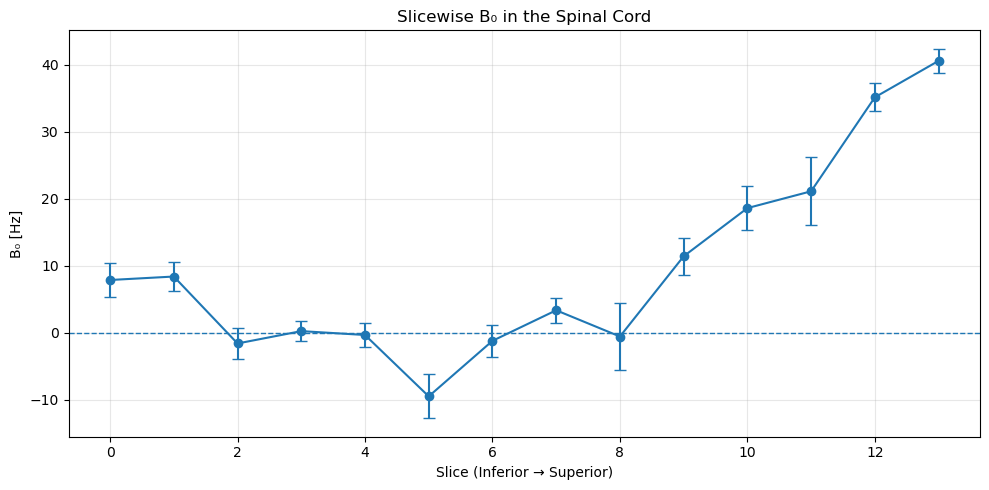

In [4]:
# Change this to "BIN()" if that's what your CSV contains
mean_col = "BIN()"

x = baseline_shim_b0_csv_df["Slice (I->S)"]
mean = baseline_shim_b0_csv_df[mean_col]
std = baseline_shim_b0_csv_df["STD()"]

plt.figure(figsize=(10, 5))

plt.errorbar(
    x,
    mean,
    yerr=std,
    marker="o",
    linestyle="-",
    capsize=4
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Slice (Inferior → Superior)")
plt.ylabel("B₀ [Hz]")
plt.title("Slicewise B₀ in the Spinal Cord")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Loading the csv for the acdc shimmed data
B0_no_reg_mcshim_csv_path = r"R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\chi_26\raw_data\chi_026\chi_026\acdc_shimm_experiment_dcms\sort_dicoms\niftis\acdc_shim_no_reg\fmap_tests\B0_no_reg_mcshim_slicewise_stats.csv"
B0_no_reg_mcshim_csv_df = pd.read_csv(B0_no_reg_mcshim_csv_path)

B0_w_reg_mcshim_csv_path = r"R:\soothsayer\sc_qsm\sc_qsm\neuropoly_data\chi_26\raw_data\chi_026\chi_026\acdc_shimm_experiment_dcms\sort_dicoms\niftis\acdc_shim_w_reg_point3\fmap_tests\B0_w_reg_mcshim_slicewise_stats.csv"
B0_w_reg_mcshim_csv_df = pd.read_csv(B0_w_reg_mcshim_csv_path)

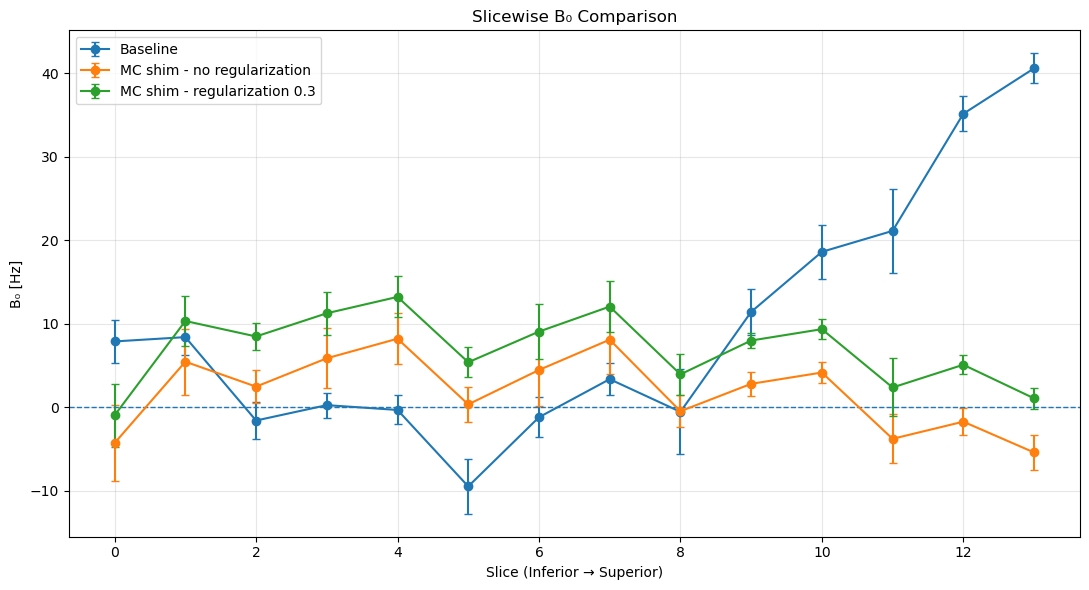

In [10]:

# Change this to plot the method you want
mean_col = "BIN()"

plt.figure(figsize=(11, 6))

# Baseline
plt.errorbar(
    baseline_shim_b0_csv_df["Slice (I->S)"],
    baseline_shim_b0_csv_df[mean_col],
    yerr=baseline_shim_b0_csv_df["STD()"],
    marker="o",
    linestyle="-",
    capsize=3,
    label="Baseline"
)

# MC shim without regularization
plt.errorbar(
    B0_no_reg_mcshim_csv_df["Slice (I->S)"],
    B0_no_reg_mcshim_csv_df[mean_col],
    yerr=B0_no_reg_mcshim_csv_df["STD()"],
    marker="o",
    linestyle="-",
    capsize=3,
    label="MC shim - no regularization"
)

# MC shim with regularization
plt.errorbar(
    B0_w_reg_mcshim_csv_df["Slice (I->S)"],
    B0_w_reg_mcshim_csv_df[mean_col],
    yerr=B0_w_reg_mcshim_csv_df["STD()"],
    marker="o",
    linestyle="-",
    capsize=3,
    label="MC shim - regularization 0.3"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Slice (Inferior → Superior)")
plt.ylabel("B₀ [Hz]")
plt.title("Slicewise B₀ Comparison")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()